In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip "/content/drive/MyDrive/Advanced Computational Tech/Final Project/archive.zip"

Archive:  /content/drive/MyDrive/Advanced Computational Tech/Final Project/archive.zip
  inflating: CamVid/class_dict.csv   
  inflating: CamVid/test/0001TP_006690.png  
  inflating: CamVid/test/0001TP_006720.png  
  inflating: CamVid/test/0001TP_006750.png  
  inflating: CamVid/test/0001TP_006780.png  
  inflating: CamVid/test/0001TP_006810.png  
  inflating: CamVid/test/0001TP_006840.png  
  inflating: CamVid/test/0001TP_006870.png  
  inflating: CamVid/test/0001TP_006900.png  
  inflating: CamVid/test/0001TP_006930.png  
  inflating: CamVid/test/0001TP_006960.png  
  inflating: CamVid/test/0001TP_006990.png  
  inflating: CamVid/test/0001TP_007020.png  
  inflating: CamVid/test/0001TP_007050.png  
  inflating: CamVid/test/0001TP_007080.png  
  inflating: CamVid/test/0001TP_007110.png  
  inflating: CamVid/test/0001TP_007140.png  
  inflating: CamVid/test/0001TP_007170.png  
  inflating: CamVid/test/0001TP_007200.png  
  inflating: CamVid/test/0001TP_007230.png  
  inflating: CamVid/

In [4]:
import os, glob, random
import cv2
import numpy as np
import pandas as pd
import random

In [5]:
train_root = '/content/CamVid/train'
val_root = '/content/CamVid/val'
test_root = '/content/CamVid/test'

In [6]:
print(f'train length:{len(os.listdir(train_root))}')
print(f'valid length:{len(os.listdir(val_root))}')
print(f'test length:{len(os.listdir(test_root))}')

train length:369
valid length:100
test length:232


In [7]:
cls_map = pd.read_csv('/content/CamVid/class_dict.csv')

colormap = {}
for idx, row in cls_map.iterrows():
    colormap[(row['r'], row['g'], row['b'])] = idx

num_classes = len(cls_map)
print(f"Number of classes: {num_classes}")

Number of classes: 32


In [8]:
def rgb_to_mask(rgb_image, colormap):
    h, w = rgb_image.shape[:2]
    mask = np.zeros((h, w), dtype=np.int64)

    for (r, g, b), idx in colormap.items():
        match_color = (
            (rgb_image[:, :, 0] == r) &
            (rgb_image[:, :, 1] == g) &
            (rgb_image[:, :, 2] == b)
        )
        mask[match_color] = idx

    return mask

# Data Prepration

In [9]:
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import matplotlib.pyplot as plt

In [10]:
img_size = 384

train_transform = A.Compose([
    A.Resize(img_size, img_size),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.1, p=0.5),
    A.ToFloat(max_value=255.0),
    ToTensorV2()
], additional_targets={'mask': 'mask'})

transform = A.Compose([
    A.Resize(img_size, img_size),
    A.ToFloat(max_value=255.0),
    ToTensorV2()
], additional_targets={'mask': 'mask'})

class Dataset(data.Dataset):
  def __init__(self, img_dir, mask_dir, colormap, transform=None):
    super().__init__()
    self.img_dir = img_dir
    self.mask_dir = mask_dir
    self.colormap = colormap
    self.transform = transform
    self.filenames = sorted(os.listdir(img_dir))

  def __len__(self):
    return len(self.filenames)

  def __getitem__(self, idx):
    img_name  = self.filenames[idx]
    mask_name = img_name.replace('.png', '_L.png')

    image    = np.array(Image.open(os.path.join(self.img_dir,  img_name )).convert('RGB'))
    mask_rgb = np.array(Image.open(os.path.join(self.mask_dir, mask_name)).convert('RGB'))
    mask     = rgb_to_mask(mask_rgb, self.colormap).astype(np.uint8)

    if self.transform is not None:
        augmented = self.transform(image=image, mask=mask)
        image = augmented['image']  # tensor [3, H, W]
        mask  = augmented['mask']   # tensor [H, W]

    mask = mask.long()

    return image, mask

In [11]:
trainset = Dataset(img_dir=train_root,
                   mask_dir='/content/CamVid/train_labels',
                   colormap=colormap,
                   transform=train_transform)

validset = Dataset(img_dir=val_root,
                   mask_dir='/content/CamVid/val_labels',
                   colormap=colormap,
                   transform=transform)

testset = Dataset(img_dir=test_root,
                   mask_dir='/content/CamVid/test_labels',
                   colormap=colormap,
                   transform=transform)

In [12]:
trainset.__getitem__(0)[0].shape, trainset.__getitem__(0)[1].shape

(torch.Size([3, 384, 384]), torch.Size([384, 384]))

In [13]:
trainset.__len__()

369

In [15]:
# Define train loader
trainloader =  data.DataLoader(dataset=trainset,
                                           batch_size=4,
                                           shuffle=True,
                                           num_workers=2,
                                           drop_last=True)
# Define validation loader
valloader =  data.DataLoader(dataset=validset,
                                           batch_size=4,
                                           shuffle=True,
                                           num_workers=2,
                                           drop_last=True)
# Define test loader
testloader =  data.DataLoader(dataset=testset,
                                           batch_size=1,
                                           shuffle=True,
                                           num_workers=2)

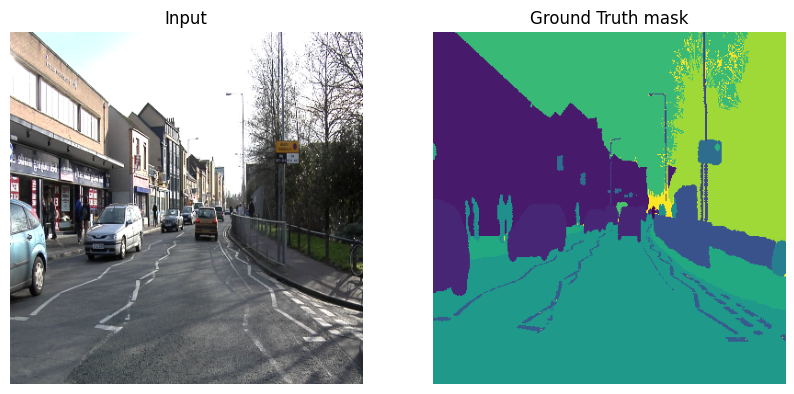

In [16]:
for inp, gt in trainloader:

    inp_img = inp[1]
    gt_img = gt[1]
    inp_img = inp_img.permute(1, 2, 0).numpy()
    gt_img = gt_img.numpy()

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Input")
    plt.imshow(inp_img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Ground Truth mask")
    plt.imshow(gt_img)
    plt.axis("off")

    plt.show()

    break

# Build The Network

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

## ViTransformer Encoder + U-Net Decoder

To use the Encoder of th transformer with U-Net Decoder We have to make a skip connection after each layer of the encoder to connect with the decoder.

### ViTransformer Encoder Arch

Patch & Tokenization

In [18]:
class PatchEmbedding(nn.Module):
  def __init__(self, patch_size, in_channels, embed_dim):
    super().__init__()
    self.proj = nn.Conv2d(in_channels,
                          embed_dim,
                          kernel_size=patch_size,
                          stride=patch_size)

  def forward(self, x):
    x = self.proj(x)        # (B, embed_dim, H, W)
    B, C, H, W = x.shape
    x = x.flatten(2)        # (B, embed_dim, n_patches)
    x = x.transpose(1, 2)   # (B, n_patches, embed_dim)
    return x

In [19]:
class PosEmbedding(nn.Module):
  def __init__(self, n_patches, embed_dim):
    super().__init__()
    # Define positional Encoding tensor
    self.pos_encoding = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
    nn.init.trunc_normal_(self.pos_encoding, std=0.02)

  def forward(self, x):
    return x + self.pos_encoding

Patch Merging

In [20]:
class DownSample(nn.Module):
  def __init__(self, embed_dim):
    super().__init__()
    self.conv = nn.Sequential(nn.Conv2d(in_channels=embed_dim,
                          out_channels=2*embed_dim,
                          kernel_size=3,
                          stride=2,
                          padding=1),
                nn.BatchNorm2d(embed_dim * 2),
                nn.GELU()
                )

  def forward(self, x):
    B, N, C = x.shape
    H = W = int(N ** 0.5)
    x = x.transpose(1, 2).reshape(B, C, H, W)
    x = self.conv(x)    # (B, 2C, H/2, W/2)
    x = x.flatten(2).transpose(1, 2)
    return x

Encoder Block

In [21]:
class EncoderStage(nn.Module):
  def __init__(self, embed_dim, n_heads, num_layers):
    super().__init__()
    self.layer = nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=n_heads,
                dim_feedforward=embed_dim * 2,
                batch_first=True,
                norm_first=True,
            )
    self.stage = nn.TransformerEncoder(self.layer, num_layers=num_layers,
                                enable_nested_tensor=False)
  def forward(self, x):
    return self.stage(x)

In [22]:
class ViTransformerEncoder(nn.Module):
  def __init__(self,
               img_size,
               patch_size=4,
               in_channels=3,
               embed_dim=96,
               n_heads=8):

    super().__init__()
    self.patch_size = patch_size
    self.n_patches = (img_size // patch_size)**2

    self.patch_embed = PatchEmbedding(patch_size, in_channels, embed_dim)
    self.pos_embed = PosEmbedding(self.n_patches, embed_dim)

    self.stages = nn.Sequential(
        # First stage
        EncoderStage(embed_dim, n_heads, num_layers=6),
        DownSample(embed_dim),

        # Second Stage
        EncoderStage(2*embed_dim, n_heads, num_layers=4),
        DownSample(2*embed_dim),

        # Third Stage
        EncoderStage(4*embed_dim, n_heads, num_layers=2),
        DownSample(4*embed_dim)
    )

  def forward(self, x):
    self.feats = []
    x = self.patch_embed(x)
    x = self.pos_embed(x)

    for module in self.stages:
      x = module(x)
      if isinstance(module, EncoderStage):
        B, N, C = x.shape
        H = W = int(N ** 0.5)
        self.feats.append(x.transpose(1,2).reshape(B, C, H, W))

    B, N, C = x.shape
    H = W = int(N ** 0.5)
    x = x.transpose(1,2).reshape(B, C, H, W)
    return x, self.feats

Test for Dimensions

In [23]:
encoder = ViTransformerEncoder(img_size=384, patch_size=6, in_channels=3, embed_dim=96, n_heads=4)

x = torch.randn(1, 3, 384, 384)

with torch.no_grad():
    out, feats = encoder(x)
    print(f"final stage shape:{out.shape}")
    print("Feature maps:")
    for i, f in enumerate(feats):
        print(f"  stage {i+1}: {f.shape}")

final stage shape:torch.Size([1, 768, 8, 8])
Feature maps:
  stage 1: torch.Size([1, 96, 64, 64])
  stage 2: torch.Size([1, 192, 32, 32])
  stage 3: torch.Size([1, 384, 16, 16])


### U-Net Decoder Arch

In [24]:
class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        return self.up(x)

In [25]:
class ViTUNetDecoder(nn.Module):
    def __init__(self, in_dim, output_size):
        super().__init__()

        self.output_size = output_size

        self.stages = nn.Sequential(
            # First Stage
            UpSample(in_dim,       in_dim // 2),
            nn.Conv2d(in_dim,      in_dim // 2, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_dim // 2),
            nn.ReLU(),

            # Second Stage
            UpSample(in_dim // 2,  in_dim // 4),
            nn.Conv2d(in_dim // 2, in_dim // 4, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_dim // 4),
            nn.ReLU(),

            # Third Stage
            UpSample(in_dim // 4,  in_dim // 8),
            nn.Conv2d(in_dim // 4, in_dim // 8, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_dim // 8),
            nn.ReLU(),

            nn.Conv2d(in_dim // 8, 32, kernel_size=1)
          )


    def forward(self, x, feats):
      skips = list(reversed(feats))
      skip_idx = 0
      for module in self.stages:
        x = module(x)
        if isinstance(module, UpSample):
          x = torch.cat([x, skips[skip_idx]], dim=1)
          skip_idx += 1

      x = F.interpolate(x, size=self.output_size, mode='bilinear', align_corners=False)
      return x

In [26]:
skip1 = torch.randn(1, 96, 64, 64)
skip2 = torch.randn(1, 192, 32, 32)
skip3 = torch.randn(1, 384, 16, 16)

decoder = ViTUNetDecoder(768, output_size=(384, 384))

x = torch.randn(1, 768, 8, 8)

with torch.no_grad():
    out = decoder(x, [skip1, skip2, skip3])

print(f"Input : {x.shape}")
print(f"Output: {out.shape}")

Input : torch.Size([1, 768, 8, 8])
Output: torch.Size([1, 32, 384, 384])


## Network Arch

In [27]:
class ViTUNet(nn.Module):
    def __init__(self,
                 img_size=256,
                 in_channels=3,
                 embed_dim=96,
                 patch_size=4,
                 n_heads=8):
        super().__init__()
        self.encoder = ViTransformerEncoder(img_size=img_size,
                                            patch_size=patch_size,
                                            in_channels=in_channels,
                                            embed_dim=embed_dim,
                                            n_heads=n_heads)

        self.decoder = ViTUNetDecoder(embed_dim*8,
                                      output_size=(img_size, img_size))

    def forward(self, x):
        input_size = x.shape[-2:]

        enout, feats = self.encoder(x)
        deout = self.decoder(enout, feats)

        return deout

In [28]:
model = ViTUNet(img_size=256, embed_dim=96, patch_size=4)
x = torch.randn(1, 3, 256, 256)

with torch.no_grad():
    out = model(x)

print(f"Input : {x.shape}")
print(f"Output: {out.shape}")

Input : torch.Size([1, 3, 256, 256])
Output: torch.Size([1, 32, 256, 256])


# Training Stage

In [29]:
import torch.optim as optim
from torchsummary import summary
from tqdm import tqdm
import numpy as np

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [31]:
# Parameters of the transformer
img_size = 384
patch_size = 6
embed_dim = 96
n_heads = 6

# Parameters of optimizer
lr = 0.0001

# Parameters of training loop
n_epochs = 30

In [32]:
in_ch = 3
model = ViTUNet(img_size=img_size,
                in_channels=in_ch,
                embed_dim=embed_dim,
                patch_size=patch_size,
                n_heads=n_heads)
model.to(device)
x = torch.randn(1, 3, img_size, img_size).to(device)
y = model(x)
print(y.shape)

torch.Size([1, 32, 384, 384])


Optimizer and Loss Criterion

In [33]:
optimizer = optim.Adam(model.parameters(), lr=lr)
loss_function = nn.CrossEntropyLoss()

Train Routine

In [34]:
def segmentation_metrics(pred, target, num_classes=32):
    pred   = pred.argmax(dim=1)                                        # [B, H, W]

    pred   = F.one_hot(pred,   num_classes).permute(0,3,1,2).float()  # [B, 32, H, W]
    target = F.one_hot(target, num_classes).permute(0,3,1,2).float()  # [B, 32, H, W]

    intersection = (pred * target).sum(dim=(2,3))                      # [B, 32]
    union        = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))         # [B, 32]

    # Dice
    dice = (2 * intersection + 1e-6) / (union + 1e-6)                 # [B, 32]
    dice = dice.mean()

    # IoU
    iou  = (intersection + 1e-6) / (union - intersection + 1e-6)      # [B, 32]
    iou  = iou.mean()

    return dice.item(), iou.item()

In [ ]:
epochs_train_losses = []
epochs_val_losses = []

epochs_train_dices = []
epochs_val_dices = []

epochs_train_ious = []
epochs_val_ious = []

best_val_loss = float('inf')

with tqdm(range(n_epochs)) as progress:

    for epoch in progress:

        batch_train_losses = []
        batch_val_losses = []

        batch_train_dices = []
        batch_val_dices = []

        batch_train_ious = []
        batch_val_ious = []

        model.train()

        for image, gt in trainloader:
            image = image.to(device)
            gt    = gt.to(device)

            optimizer.zero_grad()

            logits = model(image)

            loss = loss_function(logits, gt)

            loss.backward()

            optimizer.step()

            dice, iou = segmentation_metrics(logits, gt)
            batch_train_losses.append(loss.item())
            batch_train_dices.append(dice)
            batch_train_ious.append(iou)

        train_loss = np.mean(batch_train_losses)
        train_dice = np.mean(batch_train_dices)
        train_iou  = np.mean(batch_train_ious)

        epochs_train_losses.append(train_loss)
        epochs_train_dices.append(train_dice)
        epochs_train_ious.append(train_iou)

        model.eval()

        with torch.no_grad():
            for image, gt in valloader:

                image = image.to(device)
                gt    = gt.to(device)

                logits = model(image)

                loss = loss_function(logits, gt)

                dice, iou = segmentation_metrics(logits, gt)

                batch_val_losses.append(loss.item())
                batch_val_dices.append(dice)
                batch_val_ious.append(iou)

        val_loss = np.mean(batch_val_losses)
        val_dice = np.mean(batch_val_dices)
        val_iou  = np.mean(batch_val_ious)

        epochs_val_losses.append(val_loss)
        epochs_val_dices.append(val_dice)
        epochs_val_ious.append(val_iou)

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                {
                    'epoch'               : epoch + 1,
                    'model_state_dict'    : model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'train_loss'          : train_loss,
                    'val_loss'            : val_loss,
                    'train_dice'          : train_dice,
                    'val_dice'            : val_dice,
                    'train_iou'           : train_iou,
                    'val_iou'             : val_iou,
                },
                'best_model.pth'
            )

            print(
                f"\nBest model saved at epoch {epoch+1}"
                f" | val_loss={val_loss:.6f}"
                f" | val_dice={val_dice:.4f}"
                f" | val_iou={val_iou:.4f}"
            )

        progress.set_postfix(
            {
                'train_loss': f'{train_loss:.6f}',
                'val_loss'  : f'{val_loss:.6f}',
                'train_dice': f'{train_dice:.4f}',
                'val_dice'  : f'{val_dice:.4f}',
                'train_iou' : f'{train_iou:.4f}',
                'val_iou'   : f'{val_iou:.4f}',
            }
        )

        # Save last model
        torch.save(
            {
                'epoch'               : epoch + 1,
                'model_state_dict'    : model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss'          : train_loss,
                'val_loss'            : val_loss,
                'train_dice'          : train_dice,
                'val_dice'            : val_dice,
                'train_iou'           : train_iou,
                'val_iou'             : val_iou,
            },
            'last_model.pth'
        )

print(f"Last model saved at epoch {epoch+1}")

  0%|          | 0/30 [01:29<?, ?it/s, train_loss=2.371341, val_loss=1.999593, train_dice=0.3349, val_dice=0.5342, train_iou=0.3225, val_iou=0.5209]


Best model saved at epoch 1 | val_loss=1.999593 | val_dice=0.5342 | val_iou=0.5209


  3%|▎         | 1/30 [03:00<43:43, 90.45s/it, train_loss=1.716164, val_loss=1.573786, train_dice=0.5435, val_dice=0.5622, train_iou=0.5291, val_iou=0.5466]


Best model saved at epoch 2 | val_loss=1.573786 | val_dice=0.5622 | val_iou=0.5466


  7%|▋         | 2/30 [04:33<42:22, 90.81s/it, train_loss=1.465451, val_loss=1.497932, train_dice=0.5684, val_dice=0.5500, train_iou=0.5519, val_iou=0.5378]

...


Best model saved at epoch 29 | val_loss=0.550693 | val_dice=0.6476 | val_iou=0.6170


 97%|█████████▋| 29/30 [47:39<01:36, 96.78s/it, train_loss=0.420858, val_loss=0.534229, train_dice=0.6740, val_dice=0.6604, train_iou=0.6430, val_iou=0.6293]


Best model saved at epoch 30 | val_loss=0.534229 | val_dice=0.6604 | val_iou=0.6293


100%|██████████| 30/30 [47:40<00:00, 95.34s/it, train_loss=0.420858, val_loss=0.534229, train_dice=0.6740, val_dice=0.6604, train_iou=0.6430, val_iou=0.6293]

Last model saved at epoch 30


In [37]:
checkpoint = torch.load('/content/drive/MyDrive/Advanced Computational Tech/Final Project/best_model.pth',
                        map_location=device,
                        weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])

epoch = checkpoint['epoch']
train_loss = checkpoint['train_dice']
val_loss = checkpoint['val_dice']

print(f"Loaded best model from epoch {epoch}")
print(f"Validation acc: {val_loss:.6f}")

Loaded best model from epoch 30
Validation acc: 0.660384


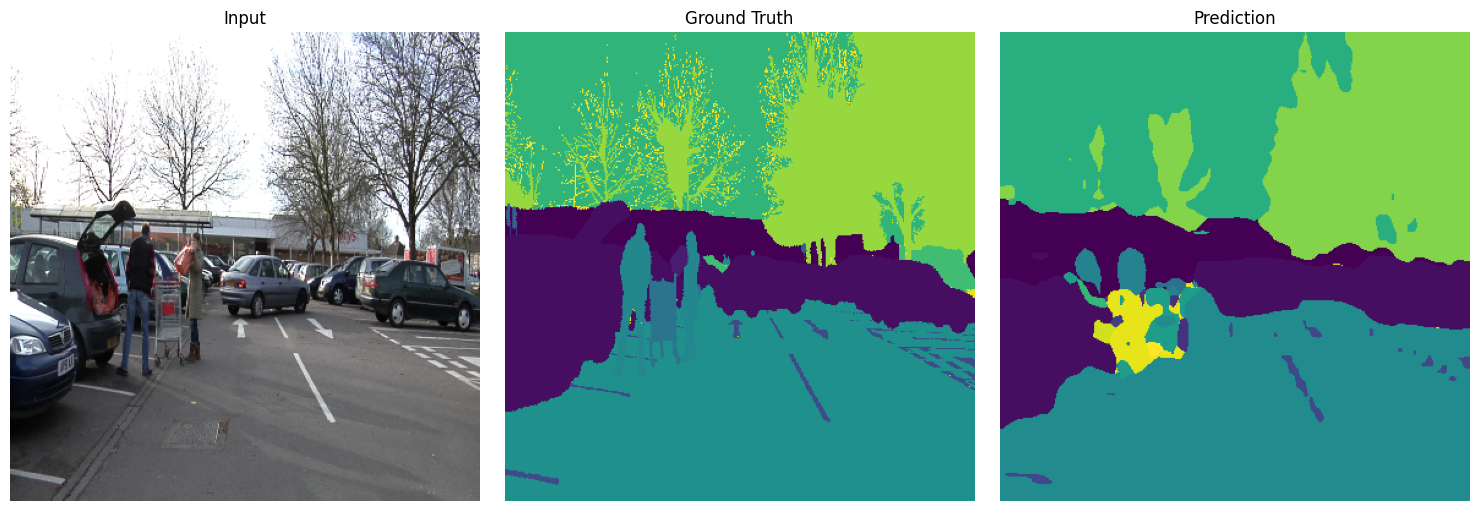

In [38]:
model.eval()
with torch.no_grad():
    for image, gt in testloader:
        image = image.to(device)
        pred  = model(image)

        orig_img = image[0].cpu().permute(1, 2, 0).numpy()  # [H, W, 3]
        gt_img   = gt[0].cpu().numpy()                       # [H, W]
        pred_img = pred[0].argmax(dim=0).cpu().numpy()       # [H, W]

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(orig_img)  ; axes[0].set_title("Input")       ; axes[0].axis("off")
        axes[1].imshow(gt_img)    ; axes[1].set_title("Ground Truth"); axes[1].axis("off")
        axes[2].imshow(pred_img)  ; axes[2].set_title("Prediction")  ; axes[2].axis("off")
        plt.tight_layout()
        plt.show()
        break

## Metrics Evaluation

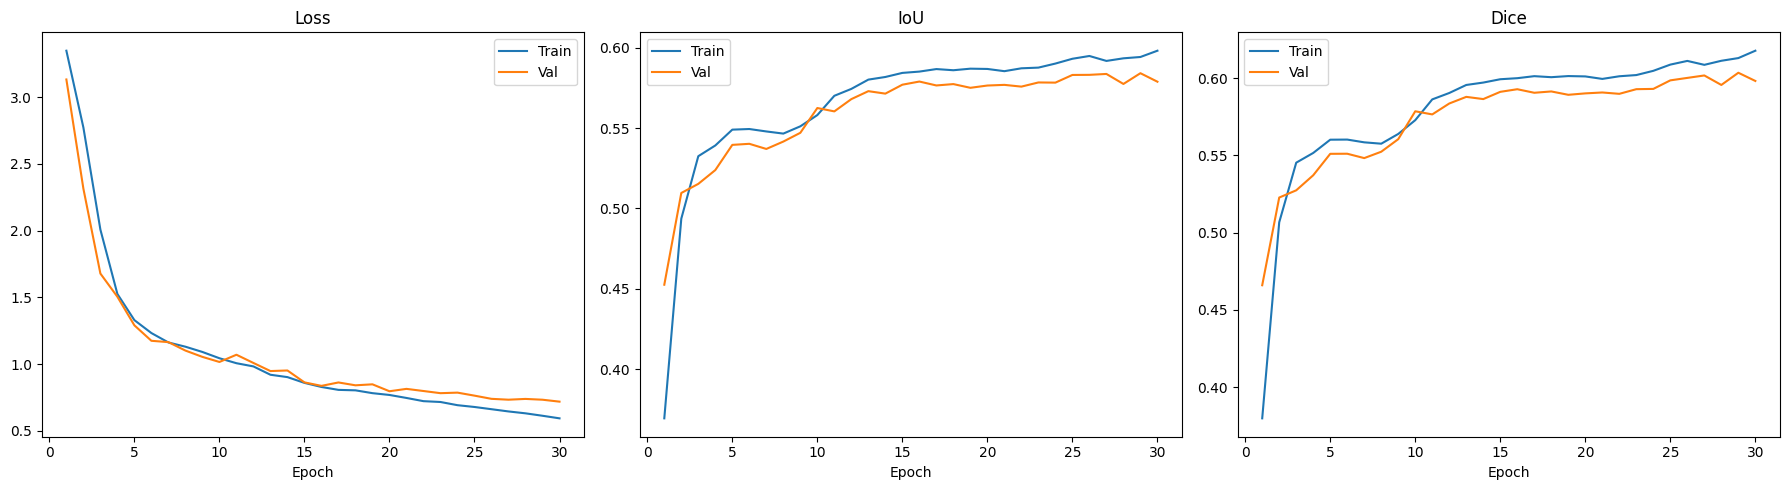

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(epochs_train_losses) + 1)

# Loss
axes[0].plot(epochs, epochs_train_losses, label='Train')
axes[0].plot(epochs, epochs_val_losses,   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# IoU
axes[1].plot(epochs, epochs_train_ious, label='Train')
axes[1].plot(epochs, epochs_val_ious,   label='Val')
axes[1].set_title('IoU')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Dice
axes[2].plot(epochs, epochs_train_dices, label='Train')
axes[2].plot(epochs, epochs_val_dices,   label='Val')
axes[2].set_title('Dice')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

# Pretrained U-Net

In [39]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.3 MB/s eta 0:00:00


In [40]:
import segmentation_models_pytorch as smp

In [41]:
model_smp = smp.Unet(
    encoder_name         = "resnet34",
    encoder_weights      = "imagenet",
    in_channels          = 3,
    classes              = 32,
    decoder_attention_type = 'scse'
)
model_smp = model_smp.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
optimizer_smp = optim.Adam(model_smp.parameters(), lr=lr)
loss_function = nn.CrossEntropyLoss()

In [ ]:
epochs_smp_train_losses = []
epochs_smp_val_losses   = []

epochs_smp_train_dices  = []
epochs_smp_val_dices    = []

epochs_smp_train_ious   = []
epochs_smp_val_ious     = []

best_val_loss = float('inf')

with tqdm(range(n_epochs)) as progress:

    for epoch in progress:

        batch_train_losses = []
        batch_val_losses   = []
        batch_train_dices  = []
        batch_val_dices    = []
        batch_train_ious   = []
        batch_val_ious     = []

        model_smp.train()

        for image, gt in trainloader:
            image = image.to(device)
            gt    = gt.to(device)

            optimizer_smp.zero_grad()

            logits = model_smp(image)
            loss   = loss_function(logits, gt)

            loss.backward()
            optimizer_smp.step()

            dice, iou = segmentation_metrics(logits, gt)
            batch_train_losses.append(loss.item())
            batch_train_dices.append(dice)
            batch_train_ious.append(iou)

        train_loss = np.mean(batch_train_losses)
        train_dice = np.mean(batch_train_dices)
        train_iou  = np.mean(batch_train_ious)

        epochs_smp_train_losses.append(train_loss)
        epochs_smp_train_dices.append(train_dice)
        epochs_smp_train_ious.append(train_iou)

        model_smp.eval()

        with torch.no_grad():
            for image, gt in valloader:
                image = image.to(device)
                gt    = gt.to(device)

                logits = model_smp(image)
                loss   = loss_function(logits, gt)

                dice, iou = segmentation_metrics(logits, gt)

                batch_val_losses.append(loss.item())
                batch_val_dices.append(dice)
                batch_val_ious.append(iou)

        val_loss = np.mean(batch_val_losses)
        val_dice = np.mean(batch_val_dices)
        val_iou  = np.mean(batch_val_ious)

        epochs_smp_val_losses.append(val_loss)
        epochs_smp_val_dices.append(val_dice)
        epochs_smp_val_ious.append(val_iou)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(
                {
                    'epoch'               : epoch + 1,
                    'model_state_dict'    : model_smp.state_dict(),
                    'optimizer_state_dict': optimizer_smp.state_dict(),
                    'train_loss'          : train_loss,
                    'val_loss'            : val_loss,
                    'train_dice'          : train_dice,
                    'val_dice'            : val_dice,
                    'train_iou'           : train_iou,
                    'val_iou'             : val_iou,
                },
                'pretrained_best_model.pth'
            )
            print(
                f"\nBest model saved at epoch {epoch+1}"
                f" | val_loss={val_loss:.6f}"
                f" | val_dice={val_dice:.4f}"
                f" | val_iou={val_iou:.4f}"
            )

        progress.set_postfix(
            {
                'train_loss': f'{train_loss:.6f}',
                'val_loss'  : f'{val_loss:.6f}',
                'train_dice': f'{train_dice:.4f}',
                'val_dice'  : f'{val_dice:.4f}',
                'train_iou' : f'{train_iou:.4f}',
                'val_iou'   : f'{val_iou:.4f}',
            }
        )

        torch.save(
            {
                'epoch'               : epoch + 1,
                'model_state_dict'    : model_smp.state_dict(),
                'optimizer_state_dict': optimizer_smp.state_dict(),
                'train_loss'          : train_loss,
                'val_loss'            : val_loss,
                'train_dice'          : train_dice,
                'val_dice'            : val_dice,
                'train_iou'           : train_iou,
                'val_iou'             : val_iou,
            },
            'pretrained_last_model.pth'
        )

print(f"Last model saved at epoch {epoch+1}")

  0%|          | 0/30 [00:57<?, ?it/s, train_loss=1.973365, val_loss=1.493353, train_dice=0.3213, val_dice=0.4556, train_iou=0.3024, val_iou=0.4384]


Best model saved at epoch 1 | val_loss=1.493353 | val_dice=0.4556 | val_iou=0.4384


  3%|▎         | 1/30 [01:58<28:19, 58.60s/it, train_loss=1.337394, val_loss=1.091270, train_dice=0.5361, val_dice=0.5907, train_iou=0.5189, val_iou=0.5749]


Best model saved at epoch 2 | val_loss=1.091270 | val_dice=0.5907 | val_iou=0.5749


  7%|▋         | 2/30 [02:57<27:59, 60.00s/it, train_loss=1.044780, val_loss=0.916842, train_dice=0.6111, val_dice=0.6096, train_iou=0.5945, val_iou=0.5938]

...


Best model saved at epoch 27 | val_loss=0.386509 | val_dice=0.6691 | val_iou=0.6302


 90%|█████████ | 27/30 [28:54<03:01, 60.65s/it, train_loss=0.247582, val_loss=0.378812, train_dice=0.7010, val_dice=0.6752, train_iou=0.6629, val_iou=0.6367]


Best model saved at epoch 28 | val_loss=0.378812 | val_dice=0.6752 | val_iou=0.6367


100%|██████████| 30/30 [30:50<00:00, 61.69s/it, train_loss=0.243041, val_loss=0.383303, train_dice=0.7048, val_dice=0.6720, train_iou=0.6663, val_iou=0.6323]

Last model saved at epoch 30


In [42]:
checkpoint = torch.load('/content/drive/MyDrive/Advanced Computational Tech/Final Project/pretrained_best_model.pth',
                        map_location=device,
                        weights_only=False)

model_smp.load_state_dict(checkpoint['model_state_dict'])

epoch = checkpoint['epoch']
train_loss = checkpoint['train_dice']
val_loss = checkpoint['val_dice']

print(f"Loaded best pretrained model from epoch {epoch}")
print(f"Validation acc: {val_loss:.6f}")

Loaded best pretrained model from epoch 28
Validation acc: 0.675161


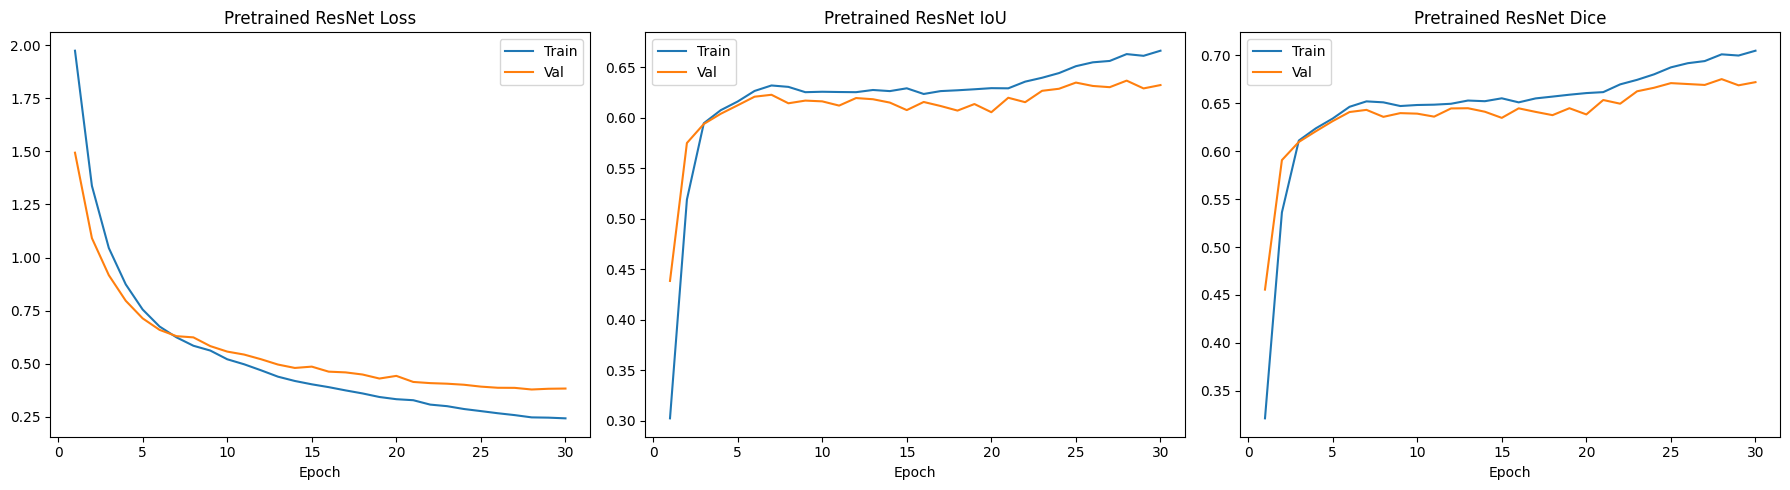

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(epochs_smp_train_losses) + 1)

# Loss
axes[0].plot(epochs, epochs_smp_train_losses, label='Train')
axes[0].plot(epochs, epochs_smp_val_losses,   label='Val')
axes[0].set_title('Pretrained ResNet Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# IoU
axes[1].plot(epochs, epochs_smp_train_ious, label='Train')
axes[1].plot(epochs, epochs_smp_val_ious,   label='Val')
axes[1].set_title('Pretrained ResNet IoU')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Dice
axes[2].plot(epochs, epochs_smp_train_dices, label='Train')
axes[2].plot(epochs, epochs_smp_val_dices,   label='Val')
axes[2].set_title('Pretrained ResNet Dice')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

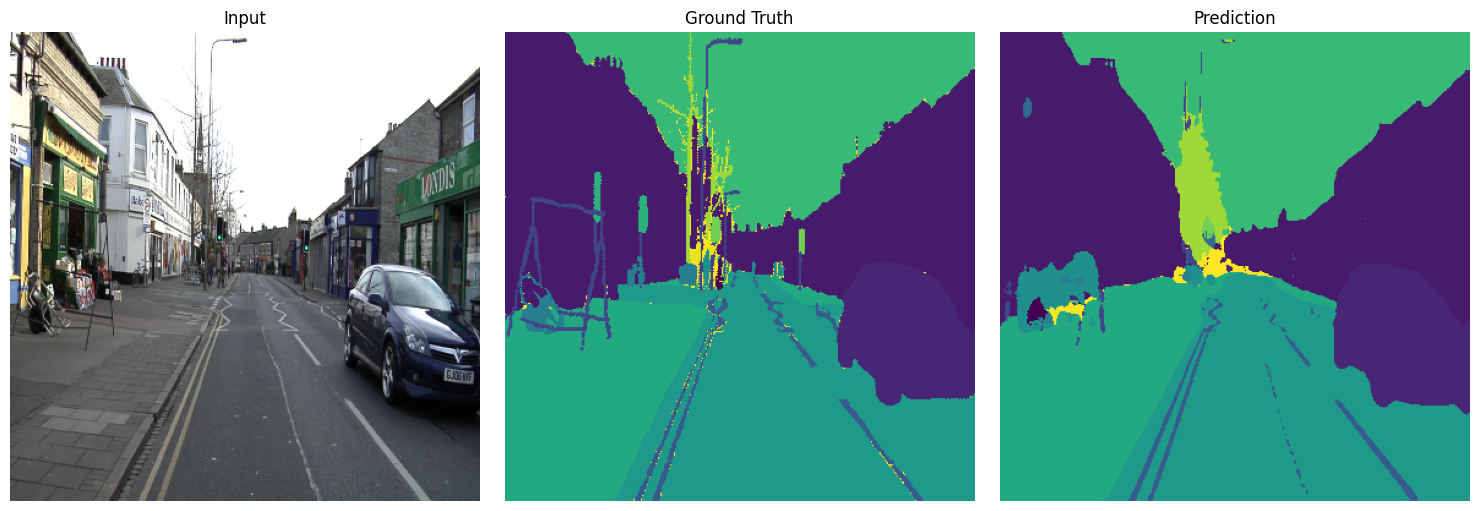

In [43]:
model_smp.eval()
with torch.no_grad():
    for image, gt in testloader:
        image = image.to(device)
        pred  = model_smp(image)

        orig_img = image[0].cpu().permute(1, 2, 0).numpy()  # [H, W, 3]
        gt_img   = gt[0].cpu().numpy()                       # [H, W]
        pred_img = pred[0].argmax(dim=0).cpu().numpy()       # [H, W]

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(orig_img)  ; axes[0].set_title("Input")       ; axes[0].axis("off")
        axes[1].imshow(gt_img)    ; axes[1].set_title("Ground Truth"); axes[1].axis("off")
        axes[2].imshow(pred_img)  ; axes[2].set_title("Prediction")  ; axes[2].axis("off")
        plt.tight_layout()
        plt.show()
        break